In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib as mpl
import matplotlib.pyplot as plt


In [2]:
# CSVをDataFrameとして読み込む
wine = pd.read_csv("winequality-red.csv", sep=";")


In [3]:
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
print(format(wine.shape))

(1599, 12)


In [5]:
#目的変数にqualityを指定、説明変数に残りの11個を指定
X = wine.drop("quality", axis=1)
t = wine["quality"]

In [6]:
print(t)

0       5
1       5
2       5
3       6
4       5
       ..
1594    5
1595    6
1596    6
1597    5
1598    6
Name: quality, Length: 1599, dtype: int64


In [7]:
X

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2


In [8]:
# 訓練データとテストデータに分割
np.random.seed(0)  # 再現性が欲しいとき
n = len(X)
perm = np.random.permutation(n)

train_ratio = 0.8
n_train = int(n * train_ratio)

train_idx = perm[:n_train]
test_idx = perm[n_train:]

X_train = X.iloc[train_idx].to_numpy()
X_test = X.iloc[test_idx].to_numpy()
t_train = t.iloc[train_idx].to_numpy()
t_test = t.iloc[test_idx].to_numpy()


In [9]:
print(X_train.shape)
print(t_train.shape)
print(t_train)

(1279, 11)
(1279,)
[6 5 7 ... 5 6 3]


In [10]:
#ここまでがデータの用意
#この先がLeast Squares Classification

In [11]:
#Least Squares Classificationにおける重みW、正解ラベルには_1をつけて区別する
#既定関数にxを用いる
from scipy import linalg
#FはXに１を加えた
F_train = np.hstack([X_train, np.ones((len(X_train), 1))])
print("F_train", F_train)
print("F_train.shape", F_train.shape)

F_test = np.hstack([X_test, np.ones((len(X_test), 1))])
print("F_test", F_test)
print("F_test.shape", F_test.shape)



F_train [[10.8    0.47   0.43  ...  0.76  10.8    1.   ]
 [ 8.1    0.82   0.    ...  0.53   9.6    1.   ]
 [ 9.1    0.29   0.33  ...  0.84  11.7    1.   ]
 ...
 [ 7.3    0.835  0.03  ...  0.47   9.6    1.   ]
 [ 7.2    0.49   0.18  ...  0.48   9.2    1.   ]
 [10.4    0.44   0.42  ...  0.86   9.9    1.   ]]
F_train.shape (1279, 12)
F_test [[ 8.3   0.28  0.48 ...  0.62 12.4   1.  ]
 [ 7.3   0.32  0.23 ...  0.62 10.1   1.  ]
 [ 7.3   0.91  0.1  ...  0.56  9.2   1.  ]
 ...
 [ 7.9   0.57  0.31 ...  0.69  9.5   1.  ]
 [13.    0.47  0.49 ...  0.68 12.7   1.  ]
 [ 9.8   0.98  0.32 ...  0.48  9.4   1.  ]]
F_test.shape (320, 12)


In [12]:

#正解クラスを1、それ以外を0とするベクトルに変換
label_to_idx = {label: idx for idx, label in enumerate(np.unique(t_train))}
T_train_1 = np.eye(len(np.unique(t_train)))[np.array([label_to_idx[label] for label in t_train])]
print("T_train_1", T_train_1)
print("T_train_1.shape", T_train_1.shape)

T_test_1 = np.eye(len(label_to_idx))[np.array([label_to_idx[label] for label in t_test])]
print("T_test_1", T_test_1)


T_train_1 [[0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 ...
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0. 0.]]
T_train_1.shape (1279, 6)
T_test_1 [[0. 0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 ...
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0.]]


In [13]:
print("トレーニングデータに含まれるクラス",np.unique(t_train))
print("テストデータに含まれるクラス",np.unique(t_test))

#   datasetの説明によると、qualityは0から10の11段階あるはずだが、全データで見られたクラスは3,4,5,6,7,8であったため6クラスとして扱った


トレーニングデータに含まれるクラス [3 4 5 6 7 8]
テストデータに含まれるクラス [4 5 6 7 8]


In [14]:
###ここでトレーニングデータ、テストデータにおいて、qualityの配列[3,4,5,6,7.8]→[0,1,2,3,4,5]と置き換える
t_train = np.argmax(T_train_1.T, axis=0)
print("t_train", t_train)
t_test = np.argmax(T_test_1.T, axis=0)
print("t_test", t_test)

t_train [3 2 4 ... 2 3 0]
t_test [4 2 2 2 5 4 2 2 4 2 3 3 4 3 3 3 3 4 2 2 2 3 3 2 2 5 2 3 2 3 2 4 2 2 2 2 2
 2 3 3 2 3 1 3 4 4 3 2 3 2 3 4 2 3 3 3 2 3 3 2 3 2 2 2 2 3 3 3 4 3 2 3 4 3
 3 3 4 2 3 2 1 3 3 1 2 3 2 1 4 3 4 2 4 2 4 3 2 2 3 4 3 4 3 2 2 3 2 3 3 4 4
 2 3 2 2 2 3 2 2 2 3 2 2 1 3 2 2 3 2 2 3 2 2 2 2 3 3 3 2 4 3 4 1 3 2 2 3 3
 2 3 2 2 3 2 2 3 3 3 4 2 2 1 3 1 4 2 2 3 4 4 4 3 3 3 4 2 4 2 3 3 3 2 1 4 3
 2 3 4 3 3 2 3 2 4 3 2 2 2 2 2 2 4 2 2 3 3 2 2 3 2 3 2 2 3 3 3 2 3 2 3 2 3
 2 2 3 2 2 3 2 4 4 3 4 2 3 2 3 3 3 2 3 1 3 2 3 3 3 4 2 3 2 2 3 2 3 4 4 4 3
 4 2 3 3 2 4 4 4 2 2 3 2 2 2 1 4 2 3 3 3 3 2 2 4 3 3 1 4 2 4 3 2 3 3 3 2 3
 3 2 2 3 2 2 2 3 3 2 2 2 1 2 3 3 3 3 2 2 2 3 3 2]


In [15]:
#二乗誤差を最小化する重みWの解析解は以下の式で与えられる。
W = np.dot(np.dot(linalg.inv(np.dot(F_train.T, F_train)), F_train.T), T_train_1)

print("W", W)
print("W.shape", W.shape)

W [[ 8.44634796e-03  2.16552224e-02 -5.04709859e-02 -1.18391340e-02
   3.79561228e-02 -5.74757332e-03]
 [ 1.09992259e-01  1.59078784e-01  3.26555763e-01 -4.43409508e-01
  -1.66465262e-01  1.42479651e-02]
 [ 4.32706874e-02  2.03933801e-02  1.42575999e-01 -2.50680285e-01
   1.27705260e-02  3.16696919e-02]
 [ 3.39399299e-03  1.59920984e-02 -1.95236261e-02 -2.72309480e-02
   2.81472309e-02 -7.78748255e-04]
 [ 1.34396492e-01 -5.71577883e-02  4.52412517e-01  3.77364264e-02
  -3.77448791e-01 -1.89938857e-01]
 [ 2.54439101e-04 -1.18475020e-03 -2.90699337e-03  4.88648920e-03
  -1.06775484e-03  1.85701015e-05]
 [-2.34991428e-04 -1.77720667e-04  3.34916009e-03 -2.39106377e-03
  -4.30019991e-04 -1.15364233e-04]
 [-6.13115830e+00 -2.20149582e+01  3.43631890e+01  2.89317956e+01
  -3.29316138e+01 -2.21725429e+00]
 [ 8.55546300e-02  1.94246960e-01 -1.74341101e-01 -5.91777862e-02
   3.33310542e-02 -7.96137578e-02]
 [-1.24176066e-02  6.99466254e-03 -4.60094410e-01  1.13489775e-01
   2.84027877e-01  6.79

In [16]:
#yは予測値
#訓練データに対して

Y_train_1 = np.dot(W.T, F_train.T)


In [17]:
#テストデータに対して

Y_test_1 = np.dot(W.T, F_test.T)
print(Y_test_1.shape)
print("Y_test_1", Y_test_1)
print("Y_test_1[;,0]", Y_test_1[:,0])

(6, 320)
Y_test_1 [[-0.0078433  -0.01111199  0.04252515 ...  0.00337492  0.00260295
   0.04743877]
 [ 0.00409914 -0.0030199   0.08893955 ...  0.04315478 -0.01044319
   0.07827122]
 [-0.01067809  0.43340682  0.80159312 ...  0.70920101  0.0893966
   1.07259958]
 [ 0.59518165  0.49222277  0.18192245 ...  0.20943594  0.57122771
  -0.05245738]
 [ 0.36559212  0.08705549 -0.10886816 ...  0.02886587  0.33451526
  -0.1238472 ]
 [ 0.05364849  0.00144681 -0.0061121  ...  0.00596748  0.01270067
  -0.02200498]]
Y_test_1[;,0] [-0.0078433   0.00409914 -0.01067809  0.59518165  0.36559212  0.05364849]


In [18]:
print(Y_train_1)

[[ 0.01247193  0.03880015 -0.01651422 ...  0.04310329  0.00069952
   0.02859502]
 [-0.01709695  0.10198971  0.00587389 ...  0.09715518  0.03670011
   0.01831084]
 [ 0.36785542  0.60924453 -0.02768507 ...  0.65440863  0.65430773
   0.33117898]
 [ 0.47277099  0.28586276  0.61330604 ...  0.28327593  0.33687822
   0.51071157]
 [ 0.15888901 -0.01820028  0.37358255 ... -0.06548445 -0.02163571
   0.11959307]
 [ 0.00510959 -0.01769688  0.0514368  ... -0.01245859 -0.00694988
  -0.00838948]]


In [19]:
#Y_train_1とY_test_1をクラスに変換
#各データから予想されるクラスは、Y_test_1,Y_train_1の列で最大の値をとるクラスのベクトルである
y_train_1 = np.argmax(Y_train_1, axis=0)
print("y_train_1", y_train_1)
y_test_1 = np.argmax(Y_test_1, axis=0)
print("y_test_1", y_test_1)


y_train_1 [3 2 3 ... 2 2 3]
y_test_1 [3 3 2 3 3 3 2 2 3 2 3 3 3 3 3 3 2 3 2 2 2 3 3 2 4 3 3 3 2 2 2 3 3 2 2 2 2
 2 3 2 2 3 2 3 3 3 3 2 3 2 2 3 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 2 2 2 2
 3 2 3 2 3 2 2 2 3 3 2 3 2 2 3 3 3 2 3 3 3 3 2 3 3 3 3 3 2 2 2 2 3 2 2 3 3
 2 2 2 3 2 3 2 2 2 3 2 2 2 2 2 2 3 2 2 3 3 2 3 2 3 2 3 2 3 2 3 2 2 2 2 2 3
 2 2 3 3 2 2 3 3 2 2 4 2 2 2 3 2 3 2 2 3 3 3 3 2 3 3 3 2 3 2 3 2 2 2 3 3 4
 3 3 3 2 2 2 2 2 3 3 2 2 2 2 2 2 3 2 2 3 3 3 2 3 2 2 2 3 2 3 3 2 3 3 3 2 2
 3 2 3 2 2 3 2 3 3 3 3 2 3 2 3 2 2 2 2 2 3 2 2 4 3 3 2 3 3 2 2 2 3 3 2 3 2
 3 2 2 2 3 3 3 3 2 2 3 3 2 3 2 3 2 3 2 3 2 2 2 3 3 3 2 3 2 3 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 3 3 2 3 2 2 2 2 2 3 3 2 2 2 2 3 2]


In [20]:
#クラス数
print(len(Y_train_1))

6


In [21]:
#trainingデータの混同行列
def confusion_matrix(t_train, y_train):
#6*6のゼロ行列を作成
    cm = np.zeros((len(Y_train_1), len(Y_train_1)), dtype=int)
    for true_label, pred_label in zip(t_train, y_train):
        cm[true_label , pred_label] += 1
    return cm
print(confusion_matrix(t_train, y_train_1))


[[  0   0   9   1   0   0]
 [  0   0  28  11   1   0]
 [  0   0 439 108   2   0]
 [  0   0 192 319   2   0]
 [  0   0  14 137   0   0]
 [  0   0   0  16   0   0]]


In [22]:
#testデータの混同行列
def confusion_matrix(t_test, y_test):
#6*6のゼロ行列を作成
    cm = np.zeros((len(Y_test_1), len(Y_test_1)), dtype=int)
    for true_label, pred_label in zip(t_test, y_test):
        cm[true_label , pred_label] += 1
    return cm
print(confusion_matrix(t_test, y_test_1))

[[  0   0   0   0   0   0]
 [  0   0  11   2   0   0]
 [  0   0 108  23   1   0]
 [  0   0  59  64   2   0]
 [  0   0   2  45   1   0]
 [  0   0   0   2   0   0]]


In [23]:
print("t_train.shape", t_train.shape)
print("Number of 2s in t_train:", sum(1 for x in t_train if x == 2))
print("Number of 3s in t_train:", sum(1 for x in t_train if x == 3))

print("t_test.shape", t_test.shape)
print("Number of 2s in t_test:", sum(1 for x in t_test if x == 2))
print("Number of 3s in t_test:", sum(1 for x in t_test if x == 3))

#データの大半がクラス（2,3)すなわちquality 5,6であることがわかる
#混合分布でクラス2,3の精度が高いのは、クラス2,3のデータが多いからであると考えられる


t_train.shape (1279,)
Number of 2s in t_train: 549
Number of 3s in t_train: 513
t_test.shape (320,)
Number of 2s in t_test: 132
Number of 3s in t_test: 125


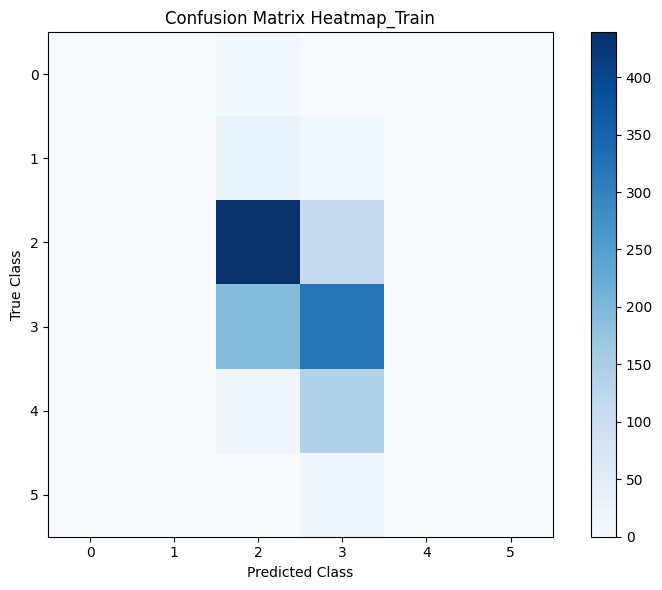

In [24]:
#trainingデータのヒートマップの作製

def heatmap_train(cm):
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title("Confusion Matrix Heatmap_Train")
    plt.colorbar()

    tick_marks = np.arange(cm.shape[0])

    plt.xticks(tick_marks)
    plt.yticks(tick_marks)

    plt.ylabel("True Class")
    plt.xlabel("Predicted Class")
    plt.tight_layout()
    plt.show()
heatmap_train(confusion_matrix(t_train, y_train_1))


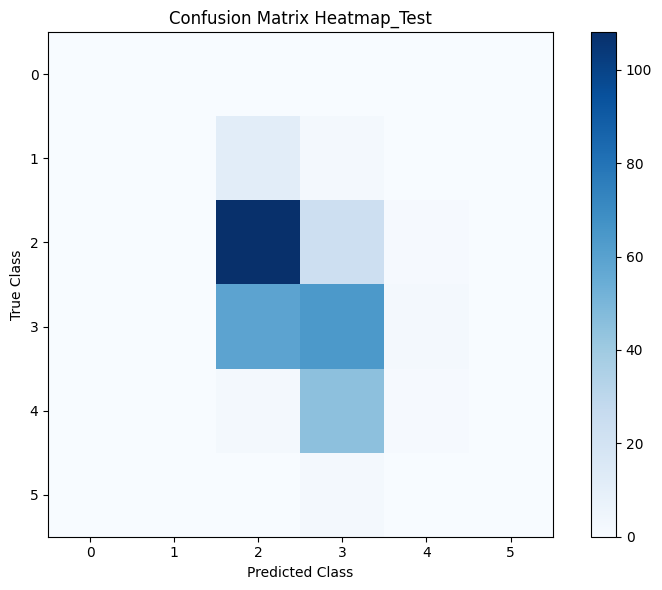

In [25]:
#testデータのヒートマップの作製

def heatmap_test(cm):
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title("Confusion Matrix Heatmap_Test",)
    plt.colorbar()

    tick_marks = np.arange(cm.shape[0])

    plt.xticks(tick_marks)
    plt.yticks(tick_marks)

    plt.ylabel("True Class")
    plt.xlabel("Predicted Class")
    plt.tight_layout()
    plt.show()
heatmap_test(confusion_matrix(t_test, y_test_1))

In [26]:
print(X_train[:,0])
print(X_train)
print(X_train.shape)

[10.8  8.1  9.1 ...  7.3  7.2 10.4]
[[10.8    0.47   0.43  ...  3.17   0.76  10.8  ]
 [ 8.1    0.82   0.    ...  3.36   0.53   9.6  ]
 [ 9.1    0.29   0.33  ...  3.26   0.84  11.7  ]
 ...
 [ 7.3    0.835  0.03  ...  3.39   0.47   9.6  ]
 [ 7.2    0.49   0.18  ...  3.29   0.48   9.2  ]
 [10.4    0.44   0.42  ...  3.38   0.86   9.9  ]]
(1279, 11)


In [27]:
#ここまでがLeast Squares Classification

In [28]:
#以下Probabilistic Generative Modelを作るための準備


In [29]:
# 1. データを各クラスごとに分ける
num_classes = len(np.unique(t_train))
X_train_classes = []
for c in range(num_classes):
    # クラス c に対応するデータだけを取り出してリストに追加
    X_train_classes.append(X_train[t_train == c])
#X_train_classesにはクラス0からクラス5まで入っている
X_train_classes


[array([[1.1600e+01, 5.8000e-01, 6.6000e-01, 2.2000e+00, 7.4000e-02,
         1.0000e+01, 4.7000e+01, 1.0008e+00, 3.2500e+00, 5.7000e-01,
         9.0000e+00],
        [1.0400e+01, 6.1000e-01, 4.9000e-01, 2.1000e+00, 2.0000e-01,
         5.0000e+00, 1.6000e+01, 9.9940e-01, 3.1600e+00, 6.3000e-01,
         8.4000e+00],
        [7.1000e+00, 8.7500e-01, 5.0000e-02, 5.7000e+00, 8.2000e-02,
         3.0000e+00, 1.4000e+01, 9.9808e-01, 3.4000e+00, 5.2000e-01,
         1.0200e+01],
        [7.3000e+00, 9.8000e-01, 5.0000e-02, 2.1000e+00, 6.1000e-02,
         2.0000e+01, 4.9000e+01, 9.9705e-01, 3.3100e+00, 5.5000e-01,
         9.7000e+00],
        [7.6000e+00, 1.5800e+00, 0.0000e+00, 2.1000e+00, 1.3700e-01,
         5.0000e+00, 9.0000e+00, 9.9476e-01, 3.5000e+00, 4.0000e-01,
         1.0900e+01],
        [6.7000e+00, 7.6000e-01, 2.0000e-02, 1.8000e+00, 7.8000e-02,
         6.0000e+00, 1.2000e+01, 9.9600e-01, 3.5500e+00, 6.3000e-01,
         9.9500e+00],
        [8.3000e+00, 1.0200e+00, 2.0000e

In [30]:
# 2. 各クラスの平均 m_train_k を求める
# m_train_kは各クラスにおけるX_trainの各特徴量の平均 (6クラス × 11特徴量)
m_train_k = np.zeros((num_classes, len(X_train.T)))
print(m_train_k.shape)
for c in range(num_classes):
    X_c = X_train_classes[c] # クラスcのデータ
    for k in range(len(X_c.T)): 
        # 元の書き方を踏襲：列の合計をデータの数で割る
        m_train_k[c, k] = X_c[:,k].sum() / len(X_c)
print(m_train_k)


(6, 11)
[[ 8.36        0.8845      0.171       2.635       0.1225     11.
  24.9         0.997464    3.398       0.57        9.955     ]
 [ 7.835       0.681       0.16475     2.6875      0.08125    11.025
  34.525       0.99649825  3.38525     0.586      10.2775    ]
 [ 8.16921676  0.5717122   0.24739526  2.51657559  0.09263024 16.96903461
  56.02367942  0.99712301  3.30590164  0.62357013  9.90856102]
 [ 8.3251462   0.49282651  0.27522417  2.42309942  0.08483041 15.74074074
  40.85575049  0.99656462  3.3211306   0.67007797 10.66692658]
 [ 8.89933775  0.41576159  0.37251656  2.79006623  0.07810596 14.0794702
  36.72847682  0.99614914  3.28668874  0.72880795 11.47130243]
 [ 8.2625      0.415625    0.365       2.4125      0.06725    14.25
  35.4375      0.99486375  3.2775      0.78       12.08125   ]]


In [31]:
# 3. クラス内共分散行列をSとする（各クラスの中心からどのくらい離れているか）
# 空の11×11行列を作成
S = np.zeros((len(X_train.T), len(X_train.T)))
for c in range(num_classes):
    X_c = X_train_classes[c]
    
    # クラスごとの中心化
    X_centered_c = X_c - m_train_k[c]
    # ブロードキャストのおかげで行列とベクトル計算可能
    
    # (X_centeredの転置行列) × (X_centered) を足し合わせる
    S += np.dot(X_centered_c.T, X_centered_c)
# 最後に全体のデータ数で割る
S = S / len(X_train)
print(S.shape)
print(S)

(11, 11)
[[ 2.98311009e+00 -6.71123335e-02  2.20637678e-01  2.03119743e-01
   7.66555850e-03 -2.80809689e+00 -5.21921708e+00  2.26132792e-03
  -1.81332157e-01  4.41468414e-02 -2.36186571e-01]
 [-6.71123335e-02  2.64974244e-02 -1.65949969e-02 -6.76022537e-04
   2.83234010e-04 -7.98515291e-02 -4.12492156e-02 -1.65680004e-05
   5.61735643e-03 -4.62660039e-03 -5.82734806e-03]
 [ 2.20637678e-01 -1.65949969e-02  3.67042265e-02  3.94398722e-02
   1.84863407e-03 -1.05265375e-01  5.88702016e-01  1.51940060e-04
  -1.55921109e-02  8.02010109e-03  6.64067589e-04]
 [ 2.03119743e-01 -6.76022537e-04  3.94398722e-02  1.67774397e+00
   1.64166023e-03  2.42571205e+00  1.00408105e+01  7.46148232e-04
  -1.45662584e-02 -7.72244110e-04  1.04251409e-01]
 [ 7.66555850e-03  2.83234010e-04  1.84863407e-03  1.64166023e-03
   2.04326621e-03 -1.01789391e-02  1.37389379e-02  1.35445100e-05
  -1.78954896e-03  2.91789726e-03 -8.47966276e-03]
 [-2.80809689e+00 -7.98515291e-02 -1.05265375e-01  2.42571205e+00
  -1.01789

In [32]:
print(m_train_k.shape)

(6, 11)


In [33]:
# 1. 重み行列 W  (クラス数 x 特徴量数)
W = np.zeros(m_train_k.shape)
# 2. クラスごとに w_k を計算して格納する
for k in range(len(m_train_k)):
    # クラス k の平均ベクトルを使って w_k を計算
    W[k] = np.dot(linalg.inv(S), m_train_k[k])


  
print("W.shape:", W.shape)
print(W)

W.shape: (6, 11)
[[-1.63900088e+03 -1.35365406e+03 -2.44545532e+02 -7.52965014e+02
  -1.74995627e+03  1.22594260e+01 -2.07779310e+00  1.74579943e+06
  -8.78968746e+03 -2.44751780e+03  1.62118020e+03]
 [-1.63940541e+03 -1.36381465e+03 -2.49728798e+02 -7.52893409e+02
  -1.77052914e+03  1.21909232e+01 -2.05501970e+00  1.74588888e+06
  -8.79513057e+03 -2.44495957e+03  1.62155734e+03]
 [-1.64028819e+03 -1.36847520e+03 -2.50150729e+02 -7.53494095e+02
  -1.76756260e+03  1.22226786e+01 -2.03968643e+00  1.74673781e+06
  -8.80224202e+03 -2.44647290e+03  1.62209091e+03]
 [-1.64014469e+03 -1.37121430e+03 -2.51305571e+02 -7.53486191e+02
  -1.76994053e+03  1.22447342e+01 -2.05753809e+00  1.74668215e+06
  -8.80219763e+03 -2.44414801e+03  1.62287207e+03]
 [-1.63973002e+03 -1.37233607e+03 -2.50716990e+02 -7.53139358e+02
  -1.77477235e+03  1.22254994e+01 -2.05898705e+00  1.74627112e+06
  -8.80197752e+03 -2.44100903e+03  1.62343155e+03]
 [-1.64048933e+03 -1.37032277e+03 -2.48381500e+02 -7.53424310e+02
  

In [34]:
print(len(X_train_classes[1]))

40


In [35]:
#Pは各クラスの事前確率を一つにまとめたベクトルとした
print(len(X_train_classes))
P = np.zeros(len(X_train_classes))
for k in range(len(X_train_classes)):
    P[k]= len(X_train_classes[k])/len(X_train)
print(P)

6
[0.00781861 0.03127443 0.42924159 0.40109461 0.11806099 0.01250977]


In [36]:
print(m_train_k[k].T)

[ 8.2625      0.415625    0.365       2.4125      0.06725    14.25
 35.4375      0.99486375  3.2775      0.78       12.08125   ]


In [37]:
#W0は各クラスのバイアス項wk0をまとめたベクトル
num_classes = len(X_train_classes)
W0 = np.zeros(num_classes)
for k in range(len(X_train_classes)):
    W0[k] = -0.5*np.dot(m_train_k[k],W[k]) + np.log(P[k])
print(W0)

[-854600.84936899 -854661.39530558 -855475.44785923 -855428.43885636
 -855032.66876224 -855091.76502159]


In [38]:
print(W[k].T.shape)
print(np.dot(X_train, W[k]) + W0[k])

(11,)
[855713.35299359 855768.74539744 854078.82884789 ... 855110.25992788
 855686.05508656 853688.71784167]


In [39]:
def a(k,x):
    a = np.dot(W[k],x) + W0[k]
    return a
a(0,X_train[0])



np.float64(855712.279976265)

In [40]:
# クラスkの事後確率p(k,x)とする
def s(x):
    # オーバーフローを防ぐため、全クラスのスコアの最大値を求める
    max_a = np.max([a(j, x) for j in range(num_classes)])
    
    s_val = 0
    for k in range(num_classes):
        # 最大値を引いてから exp を計算する
        s_val += np.exp(a(k,x) - max_a)
    return s_val
def p(k,x):
    # 分子でも同じように最大値を引いてから計算する
    max_a = np.max([a(j, x) for j in range(num_classes)])
    
    prob = np.exp(a(k,x) - max_a) / s(x)
    return prob




In [41]:
#Softmax Function
def Softmax(x):
    # 1. クラス0〜5までの確率をすべて計算してリスト（配列）にする
    probs = [p(k, x) for k in range(num_classes)]
    
    # 2. 確率が一番大きい場所のインデックス（＝クラス番号）を返す
    return np.argmax(probs)
    

In [42]:

for i in range(20):
    print(Softmax(X_test[i]))


4
3
2
4
4
3
2
2
3
2
3
3
3
3
3
3
2
4
2
2


In [43]:
#Least Squares Classificationと比較するためにtrainingデータとtestデータそれぞれに対する予測結果を一つのベクトルにまとめる
y_train_2 = np.zeros(len(X_train), dtype=int)
for i in range(len(X_train)):
    y_train_2[i] = Softmax(X_train[i])
print("y_train_2", y_train_2)


y_test_2 = np.zeros(len(X_test), dtype=int)
for i in range(len(X_test)):
    y_test_2[i] = Softmax(X_test[i])
print("y_test_2", y_test_2)


y_train_2 [3 2 4 ... 2 2 3]
y_test_2 [4 3 2 4 4 3 2 2 3 2 3 3 3 3 3 3 2 4 2 2 2 3 3 3 4 3 3 4 2 3 2 4 3 2 2 2 2
 2 3 2 2 3 2 3 3 4 3 2 3 2 2 4 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 2 2 3 2
 3 2 4 2 4 2 0 2 3 3 2 3 2 2 4 3 4 3 3 3 4 3 2 3 3 4 3 3 2 2 2 2 3 2 2 4 3
 3 3 3 3 2 3 2 2 2 3 2 2 2 2 2 2 3 2 2 3 3 2 3 2 3 2 3 2 3 3 3 1 2 2 2 2 4
 2 2 3 3 2 2 3 3 2 2 4 2 2 2 3 0 4 2 2 3 3 3 3 2 3 3 4 2 3 2 4 2 2 2 3 4 5
 3 3 3 2 2 2 2 2 3 4 2 2 2 2 2 2 4 2 2 3 3 3 2 3 2 3 2 3 2 3 1 2 3 3 3 3 2
 3 2 3 2 2 3 2 4 3 3 3 2 3 2 3 2 2 2 3 2 3 2 3 5 4 3 2 3 3 2 3 2 3 3 2 3 2
 4 2 2 2 3 3 3 4 2 2 3 3 3 3 3 3 2 3 2 4 2 2 0 3 4 3 2 3 2 3 2 2 2 3 2 2 3
 2 2 2 3 2 2 2 3 3 2 3 2 2 2 2 2 3 3 2 2 2 2 3 2]


In [44]:
#ここまでがProbabilistic Generative Model
#ここからがLeast Squares ClassificationとProbabilistic Generative Modelの比較

In [45]:
#まずはLeast Squares Classification

In [46]:
#Least Squares Classificationの正答率
# --- 訓練データ (Training Data) の精度 ---
print("Least Squares Classificationの正答率")
cnt_train_1 = 0
for i in range(len(y_train_1)):
    if y_train_1[i] == t_train[i]:
     cnt_train_1 += 1
acc_train_1 = cnt_train_1/len(y_train_1)
print(f"訓練データの正答率 : {acc_train_1 * 100:.2f}%")

# --- テストデータ (Test Data) の精度 ---
cnt_test_1 =0
for i in range(len(y_test_1)):
    if y_test_1[i] == t_test[i]:
     cnt_test_1 += 1
acc_test_1 = cnt_test_1/len(y_test_1)
print(f"テストデータの正答率 : {acc_test_1 * 100:.2f}%")

Least Squares Classificationの正答率
訓練データの正答率 : 59.27%
テストデータの正答率 : 54.06%


In [47]:
print(confusion_matrix(t_train, y_train_1))

[[  0   0   9   1   0   0]
 [  0   0  28  11   1   0]
 [  0   0 439 108   2   0]
 [  0   0 192 319   2   0]
 [  0   0  14 137   0   0]
 [  0   0   0  16   0   0]]


In [48]:
print(confusion_matrix(t_test, y_test_1))

[[  0   0   0   0   0   0]
 [  0   0  11   2   0   0]
 [  0   0 108  23   1   0]
 [  0   0  59  64   2   0]
 [  0   0   2  45   1   0]
 [  0   0   0   2   0   0]]


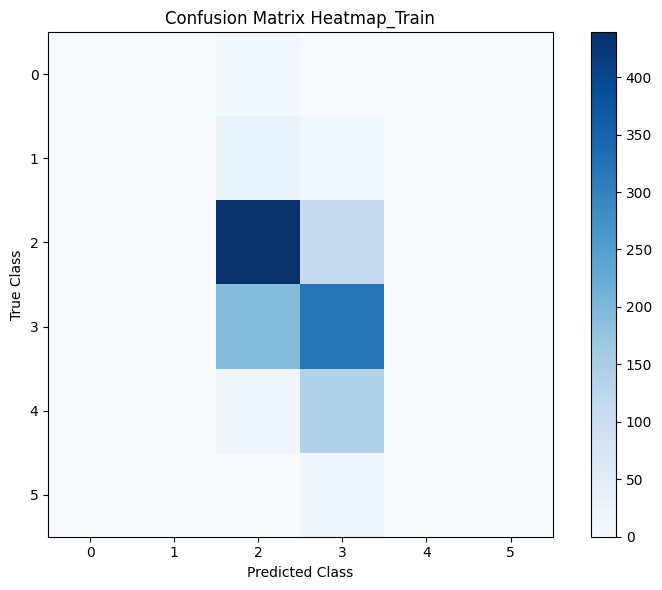

In [49]:
heatmap_train(confusion_matrix(t_train, y_train_1))

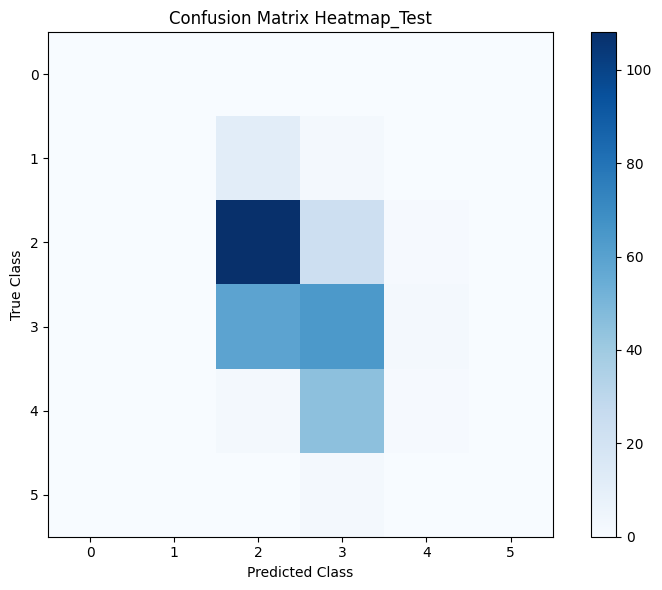

In [50]:
heatmap_test(confusion_matrix(t_test, y_test_1))

In [51]:
#次にProbabilistic Generative Model

In [52]:
#Probabilistic Generative Modelの正答率
# --- 訓練データ (Training Data)  ---
print("Probabilistic Generative Modelの正答率")
cnt_train_2 =0
for i in range(len(y_train_2)):
    if y_train_2[i] == t_train[i]:
     cnt_train_2 += 1
acc_train_2 = cnt_train_2/len(y_train_2)
print(f"訓練データの正答率 : {acc_train_2 * 100:.2f}%")

# --- テストデータ (Test Data)  ---
cnt_test_2 =0
for i in range(len(y_test_2)):
    if y_test_2[i] == t_test[i]:
     cnt_test_2 += 1
acc_test_2 = cnt_test_2/len(y_test_2)
print(f"テストデータの正答率 : {acc_test_2 * 100:.2f}%")

Probabilistic Generative Modelの正答率
訓練データの正答率 : 60.36%
テストデータの正答率 : 58.13%


In [53]:
print(confusion_matrix(t_train, y_train_2))

[[  2   0   7   1   0   0]
 [  3   1  21  13   2   0]
 [  6   3 412 122   4   2]
 [  1   2 167 301  40   2]
 [  0   0  12  82  56   1]
 [  0   0   0   9   7   0]]


In [54]:
print(confusion_matrix(t_test, y_test_2))

[[  0   0   0   0   0   0]
 [  2   1   7   3   0   0]
 [  1   0 101  28   2   0]
 [  0   1  49  65   8   2]
 [  0   0   1  28  19   0]
 [  0   0   0   1   1   0]]


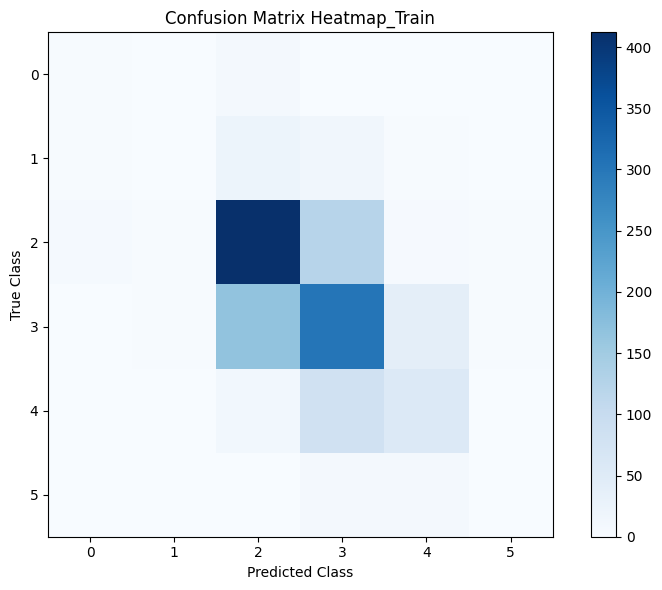

In [55]:
heatmap_train(confusion_matrix(t_train, y_train_2))

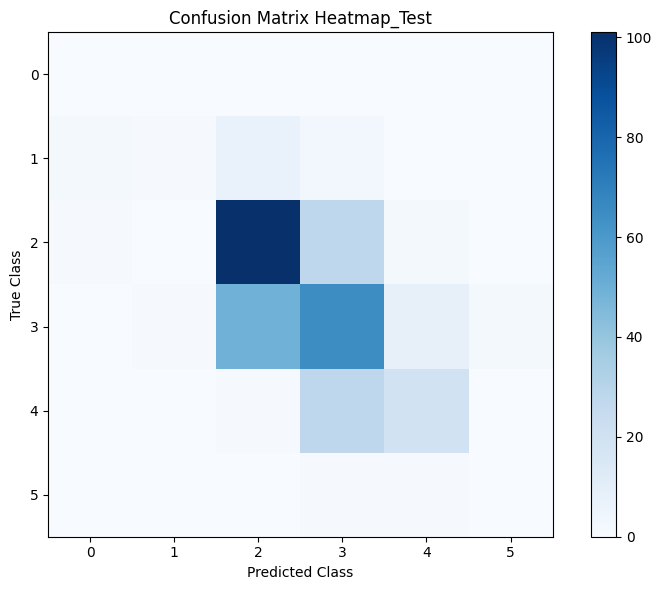

In [56]:
heatmap_test(confusion_matrix(t_test, y_test_2))